# Class 02 — Introduction to Causal Inference
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

*Rubin Causal Model / Potential Outcomes Framework*

---

**Contents:**
1. [Setup](#1)
2. [The Fundamental Problem of Causal Inference](#2)
3. [Selection Bias — The Vitamin C Example](#3)
4. [Why Naive Observational Estimates Fail](#4)
5. [Randomization Fixes Selection Bias](#5)
6. [Covariate Averaging Under Randomization](#6)
7. [Sensitivity Analysis — How Much Hidden Confounding?](#7)

---

<a id='1'></a>
## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams.update({'figure.dpi':120,'font.family':'DejaVu Sans',
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titlesize':13,'axes.labelsize':11})
BLUE='#2563EB'; RED='#DC2626'; GREEN='#16A34A'; ORANGE='#D97706'; GRAY='#6B7280'
print('Ready.')

Ready.


<a id='2'></a>
## 2. The Fundamental Problem of Causal Inference

For individual $i$, define potential outcomes $Y_i(1)$ (treated) and $Y_i(0)$ (control).  
We observe only $Y_i = T_i Y_i(1) + (1-T_i) Y_i(0)$ — never both simultaneously.

The unobserved outcome is the **counterfactual**. This is not a data collection problem — it is logically impossible.

We can only estimate the **Average Treatment Effect (ATE)**:
$$\text{ATE} = E[Y_i(1)] - E[Y_i(0)]$$

In [3]:
n = 10
# Simulate the full potential outcomes table (oracle view)
rng = np.random.default_rng(1)
Y0 = rng.binomial(1, 0.4, n)   # potential outcomes under control
Y1 = rng.binomial(1, 0.7, n)   # potential outcomes under treatment
tau_i = Y1 - Y0                  # individual treatment effects

# Assign treatment: first 5 to control, last 5 to treatment
T = np.array([0]*5 + [1]*5)
Y_obs = np.where(T==1, Y1, Y0)

df_po = pd.DataFrame({'T': T, 'Y_obs': Y_obs,
                       'Y(0)': [f'{y}' if t==0 else f'{y}*' for y,t in zip(Y0,T)],
                       'Y(1)': [f'{y}*' if t==0 else f'{y}' for y,t in zip(Y1,T)],
                       'τ_i (unobservable)': tau_i})
print("Potential Outcomes Table  (* = counterfactual, unobserved)")
print(df_po.to_string(index=True))
print(f"\nTrue ATE = {tau_i.mean():.3f}")
print(f"Naive estimate = {Y_obs[T==1].mean() - Y_obs[T==0].mean():.3f}  (biased — self-selection)")

Potential Outcomes Table  (* = counterfactual, unobserved)
   T  Y_obs Y(0) Y(1)  τ_i (unobservable)
0  0      0    0   0*                   0
1  0      1    1   1*                   0
2  0      0    0   1*                   1
3  0      1    1   0*                  -1
4  0      0    0   1*                   1
5  1      1   0*    1                   1
6  1      1   1*    1                   0
7  1      1   0*    1                   1
8  1      1   0*    1                   1
9  1      1   0*    1                   1

True ATE = 0.500
Naive estimate = 0.600  (biased — self-selection)


<a id='3'></a>
## 3. Selection Bias — The Vitamin C Example

The slides walk through a case where the true ATE = 0 but the observational estimate = 1.  
Sick people take vitamin C; healthy people don't. The correlation is driven entirely by selection.

In [4]:
# Reproduce the slide table exactly
data = {
    'T':    [0,0,0,0,1,1,1,1],
    'Y':    [0,0,0,0,1,1,1,1],
    'Y(0)': [0,0,0,0,'*1','*1','*1','*1'],
    'Y(1)': ['0*','0*','0*','0*',1,1,1,1],
}
df_vitc = pd.DataFrame(data)
print("Vitamin C example — * denotes counterfactual")
print(df_vitc.to_string(index=False))

obs_diff = df_vitc[df_vitc.T==1].Y.mean() - df_vitc[df_vitc.T==0].Y.mean()
# True potential outcomes
Y0_true = [0,0,0,0,1,1,1,1]  # from the table (counterfactuals filled in)
Y1_true = [0,0,0,0,1,1,1,1]
true_ate = np.mean(Y1_true) - np.mean(Y0_true)

print(f"\nObserved difference E[Y|T=1] - E[Y|T=0] = {obs_diff:.1f}  (looks like vitamin C helps!)")
print(f"True ATE = E[Y(1)] - E[Y(0)]            = {true_ate:.1f}  (vitamin C does nothing)")
print(f"\nBias = {obs_diff - true_ate:.1f} — entirely due to selection")

Vitamin C example — * denotes counterfactual
 T  Y Y(0) Y(1)
 0  0    0   0*
 0  0    0   0*
 0  0    0   0*
 0  0    0   0*
 1  1   *1    1
 1  1   *1    1
 1  1   *1    1
 1  1   *1    1

Observed difference E[Y|T=1] - E[Y|T=0] = nan  (looks like vitamin C helps!)
True ATE = E[Y(1)] - E[Y(0)]            = 0.0  (vitamin C does nothing)

Bias = nan — entirely due to selection


<a id='4'></a>
## 4. Why Naive Observational Estimates Fail — Simulated at Scale

The mistake in the flawed proof is:
$$E[Y_i(1) \mid T_i=1] \neq E[Y_i(1)]$$

When high-risk people self-select into treatment, the treated group has a different potential outcome distribution than the full population.

In [5]:
N = 5000
rng2 = np.random.default_rng(42)

# Baseline health (higher = healthier, lower = sicker)
health = rng2.normal(0, 1, N)

# True treatment effect: constant +1 for everyone
true_effect = 1.0

# Self-selection: sicker people (low health) more likely to seek treatment
p_treat = 1 / (1 + np.exp(health))   # sigmoid: low health → high P(T=1)
T_obs = rng2.binomial(1, p_treat)

# Potential outcomes
Y0 = health + rng2.normal(0, 0.5, N)
Y1 = health + true_effect + rng2.normal(0, 0.5, N)
Y_obs = np.where(T_obs==1, Y1, Y0)

# Naive estimate
naive_est = Y_obs[T_obs==1].mean() - Y_obs[T_obs==0].mean()

print(f"True ATE:                          {true_effect:.3f}")
print(f"Naive observational estimate:      {naive_est:.3f}")
print(f"Bias:                              {naive_est - true_effect:.3f}")
print()
print(f"E[Y(1) | T=1] = {Y1[T_obs==1].mean():.3f}   (potential outcome of treated)")
print(f"E[Y(1)]       = {Y1.mean():.3f}   (population average)")
print(f"Selection bias = {Y1[T_obs==1].mean() - Y1.mean():.3f}  ← this is what breaks the naive proof")

True ATE:                          1.000
Naive observational estimate:      0.213
Bias:                              -0.787

E[Y(1) | T=1] = 0.593   (potential outcome of treated)
E[Y(1)]       = 1.000   (population average)
Selection bias = -0.407  ← this is what breaks the naive proof


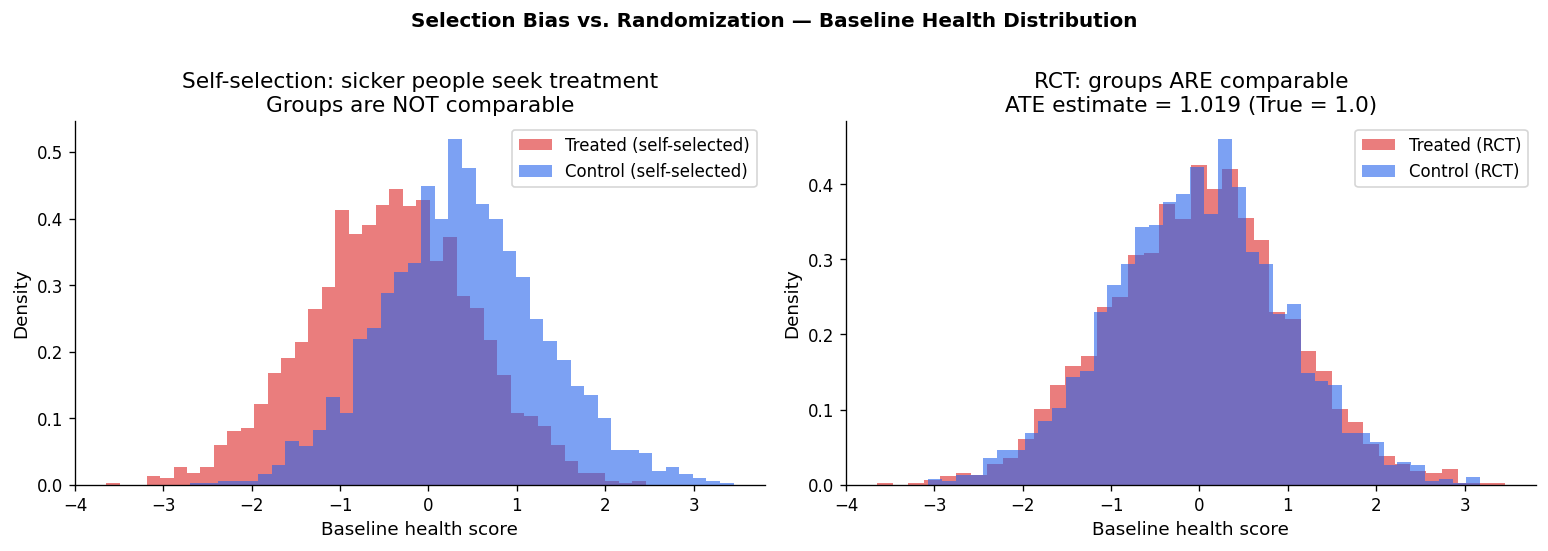

Saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(health[T_obs==1], bins=40, alpha=0.6, color=RED,  density=True, label='Treated (self-selected)')
ax.hist(health[T_obs==0], bins=40, alpha=0.6, color=BLUE, density=True, label='Control (self-selected)')
ax.set_xlabel('Baseline health score'); ax.set_ylabel('Density')
ax.set_title('Self-selection: sicker people seek treatment\nGroups are NOT comparable')
ax.legend()

ax2 = axes[1]
T_rct = rng2.binomial(1, 0.5, N)
Y_rct = np.where(T_rct==1, Y1, Y0)
rct_est = Y_rct[T_rct==1].mean() - Y_rct[T_rct==0].mean()
ax2.hist(health[T_rct==1], bins=40, alpha=0.6, color=RED,  density=True, label='Treated (RCT)')
ax2.hist(health[T_rct==0], bins=40, alpha=0.6, color=BLUE, density=True, label='Control (RCT)')
ax2.set_xlabel('Baseline health score'); ax2.set_ylabel('Density')
ax2.set_title(f'RCT: groups ARE comparable\nATE estimate = {rct_est:.3f} (True = {true_effect})')
ax2.legend()

plt.suptitle('Selection Bias vs. Randomization — Baseline Health Distribution',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/02_selection_vs_rct.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='5'></a>
## 5. Randomization Fixes Selection Bias

Under randomization: $T_i \perp (Y_i(1), Y_i(0), X_i)$

This makes the flawed step valid:
$$E[Y_i(1) \mid T_i=1] = E[Y_i(1)]$$

We verify both sides numerically across many simulated RCTs.

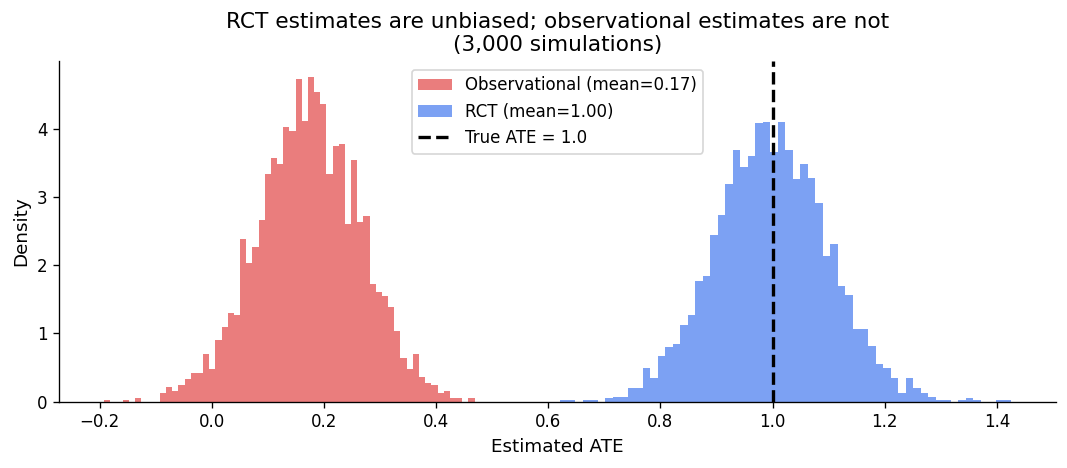

Saved.


In [7]:
n_sims = 3000
naive_ests = []
rct_ests   = []
rng3 = np.random.default_rng(10)

for _ in range(n_sims):
    health_s = rng3.normal(0, 1, 500)
    Y0_s = health_s + rng3.normal(0,0.5,500)
    Y1_s = health_s + 1.0 + rng3.normal(0,0.5,500)

    # Observational
    p_t = 1/(1+np.exp(health_s))
    T_s = rng3.binomial(1, p_t)
    Y_s = np.where(T_s==1, Y1_s, Y0_s)
    naive_ests.append(Y_s[T_s==1].mean() - Y_s[T_s==0].mean())

    # RCT
    T_r = rng3.binomial(1, 0.5, 500)
    Y_r = np.where(T_r==1, Y1_s, Y0_s)
    rct_ests.append(Y_r[T_r==1].mean() - Y_r[T_r==0].mean())

naive_ests = np.array(naive_ests)
rct_ests   = np.array(rct_ests)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(naive_ests, bins=60, alpha=0.6, color=RED,  density=True,
        label=f'Observational (mean={naive_ests.mean():.2f})')
ax.hist(rct_ests,   bins=60, alpha=0.6, color=BLUE, density=True,
        label=f'RCT (mean={rct_ests.mean():.2f})')
ax.axvline(1.0, color='black', lw=2, ls='--', label='True ATE = 1.0')
ax.set_xlabel('Estimated ATE'); ax.set_ylabel('Density')
ax.set_title('RCT estimates are unbiased; observational estimates are not\n(3,000 simulations)')
ax.legend(); plt.tight_layout()
plt.savefig('figures/03_rct_unbiased.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='6'></a>
## 6. Covariate Averaging Under Randomization

The slides show that under randomization, covariates get "averaged out":

$$E[Y_i \mid T_i=1] = \int E[Y_i(1) \mid X_i=x] \cdot P(X_i=x)\, dx = E[Y_i(1)]$$

We verify this numerically: stratify by covariate, compute treatment effect in each stratum, take weighted average.

In [8]:
# Covariate: age group (young=0, old=1)
# Treatment effect varies by age: young +0.5, old +2.0
N2 = 2000
rng4 = np.random.default_rng(5)
age_group = rng4.binomial(1, 0.5, N2)   # 50% young, 50% old
true_cate = np.where(age_group==0, 0.5, 2.0)   # CATE by subgroup
true_ate_w = 0.5*0.5 + 0.5*2.0   # weighted average = 1.25

T_rct2 = rng4.binomial(1, 0.5, N2)
Y0_2   = age_group * 2 + rng4.normal(0, 0.5, N2)
Y1_2   = Y0_2 + true_cate
Y_rct2 = np.where(T_rct2==1, Y1_2, Y0_2)

# Overall RCT estimate
overall_rct = Y_rct2[T_rct2==1].mean() - Y_rct2[T_rct2==0].mean()

# Within strata
cate_young = Y_rct2[(T_rct2==1)&(age_group==0)].mean() - Y_rct2[(T_rct2==0)&(age_group==0)].mean()
cate_old   = Y_rct2[(T_rct2==1)&(age_group==1)].mean() - Y_rct2[(T_rct2==0)&(age_group==1)].mean()
weighted   = 0.5*cate_young + 0.5*cate_old

print(f'True ATE (weighted average of CATEs): {true_ate_w:.3f}')
print(f'Overall RCT estimate:                 {overall_rct:.3f}')
print(f'CATE young:  {cate_young:.3f}  (True = 0.5)')
print(f'CATE old:    {cate_old:.3f}  (True = 2.0)')
print(f'Weighted avg of CATEs: {weighted:.3f}')
print('Randomization automatically averages over the covariate distribution.')

True ATE (weighted average of CATEs): 1.250
Overall RCT estimate:                 1.176
CATE young:  0.478  (True = 0.5)
CATE old:    1.951  (True = 2.0)
Weighted avg of CATEs: 1.215
Randomization automatically averages over the covariate distribution.


<a id='7'></a>
## 7. Sensitivity Analysis — How Much Hidden Confounding Would Overturn a Result?

Even with a significant observational result, we can ask: how large would an unmeasured confounder need to be to explain away the finding? This is **Rosenbaum's sensitivity analysis** concept.

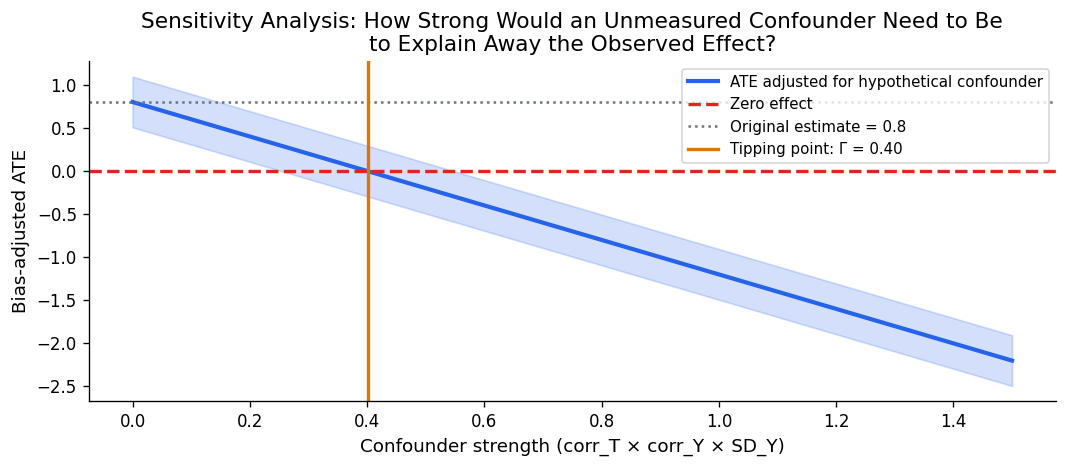

The result is robust to confounders weaker than 0.40


In [9]:
# Simulate: we found an observational ATE of 0.8
# How much unmeasured confounding would drive this to zero?
obs_result = 0.8
obs_se     = 0.15

# Sensitivity: add hypothetical confounder of increasing strength
confounder_strengths = np.linspace(0, 1.5, 300)
# Simplified: confounder bias ≈ corr_with_T * corr_with_Y * SD_Y
# Assume SD_Y = 2, vary the product of correlations
sd_y = 2.0
bias_from_confounder = confounder_strengths * sd_y

adjusted_est = obs_result - bias_from_confounder

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(confounder_strengths, adjusted_est, color=BLUE, lw=2.5,
        label='ATE adjusted for hypothetical confounder')
ax.axhline(0, color=RED, lw=2, ls='--', label='Zero effect')
ax.axhline(obs_result, color=GRAY, lw=1.5, ls=':', label=f'Original estimate = {obs_result}')
ax.fill_between(confounder_strengths,
                adjusted_est - 1.96*obs_se,
                adjusted_est + 1.96*obs_se,
                alpha=0.2, color=BLUE)

# Find tipping point
tip_idx = np.argmax(adjusted_est <= 0)
ax.axvline(confounder_strengths[tip_idx], color=ORANGE, lw=2,
           label=f'Tipping point: Γ = {confounder_strengths[tip_idx]:.2f}')

ax.set_xlabel('Confounder strength (corr_T × corr_Y × SD_Y)')
ax.set_ylabel('Bias-adjusted ATE')
ax.set_title('Sensitivity Analysis: How Strong Would an Unmeasured Confounder Need to Be\nto Explain Away the Observed Effect?')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('figures/04_sensitivity.png', bbox_inches='tight')
plt.show()
print(f'The result is robust to confounders weaker than {confounder_strengths[tip_idx]:.2f}')

---

## 📝 Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **Fundamental problem** | Can never observe both $Y_i(1)$ and $Y_i(0)$ for the same person |
| **Counterfactual** | The potential outcome that was not realized |
| **ATE** | $E[Y(1)] - E[Y(0)]$ — the estimable population-level quantity |
| **Selection bias** | $E[Y(1) \mid T=1] \neq E[Y(1)]$ when treatment is self-selected |
| **Randomization assumption** | $T_i \perp (Y_i(1), Y_i(0), X_i)$ — makes the naive proof valid |
| **Covariate balance** | Randomization averages out all covariates automatically |
| **Vitamin C example** | ATE=0 but observed difference=1 due to pure selection |
| **Sensitivity analysis** | Quantifies how much hidden confounding would overturn the conclusion |

---

## 📚 References

- Rubin, D.B. (1974). *Estimating causal effects of treatments in randomized and nonrandomized studies.* Journal of Educational Psychology 66(5): 688–701.
- Holland, P.W. (1986). *Statistics and causal inference.* JASA 81(396): 945–960.
- Imbens, G.W. & Rubin, D.B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences.* Cambridge University Press.

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*